In [1]:
import datetime as dt
from typing import Tuple, Literal, Any, Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from cycler import cycler

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

import tensorflow as tf


2026-02-13 23:29:03.485586: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-13 23:29:03.491157: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 23:29:03.750992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 23:29:05.086282: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', 'steelblue', '#3EB489', '#6B8E23'])

In [3]:
df = pd.read_csv('data/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})

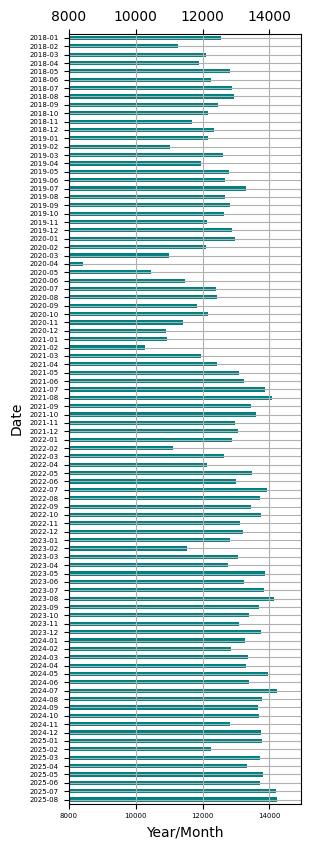

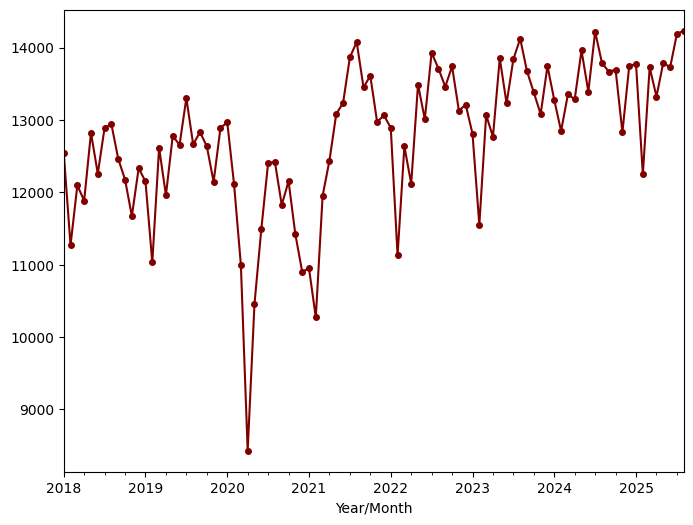

In [4]:
# year/month
grouped_by_year_month = df.groupby(by = df['Date'].dt.to_period('M')).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (3,10), xlabel='Year/Month', xlim=8000, grid=True, fontsize=5)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (8,6), xlabel='Year/Month', color='maroon', marker='o', markersize=4)
plt.show()


In [5]:
df['Date'] = df['Date'] + pd.to_timedelta(df['Hour'], unit='h')
df = df.drop('Hour', axis=1)

In [6]:
grouped_by_site_hour = df.groupby(by=[df.Site ,df.Date]).agg(
    unique_entry_per_day=('Date', 'size'),
    total_encounters=('ED Enc', 'sum'),
    total_admissions=('ED Enc Admitted', 'sum')
)

grouped_by_site_hour

unique_entry_per_day  total_encounters  \
Site Date                                                          
A    2018-01-01 00:00:00                     4                 4   
     2018-01-01 01:00:00                     2                 2   
     2018-01-01 02:00:00                     2                 2   
     2018-01-01 03:00:00                     2                 2   
     2018-01-01 04:00:00                     2                 2   
...                                        ...               ...   
D    2025-08-31 18:00:00                     8                 9   
     2025-08-31 19:00:00                     3                 3   
     2025-08-31 20:00:00                     7                 8   
     2025-08-31 22:00:00                     2                 2   
     2025-08-31 23:00:00                     4                 4   

                          total_admissions  
Site Date                                   
A    2018-01-01 00:00:00                 2  
     2018-01-01 01:00:00                 1  
     2018-01-01 02:00:00                 0  
     2018-01-01 03:00:00                 1  
     2018-01-01 04:00:00                 0  
...                                    ...  
D    2025-08-31 18:00:00                 2  
     2025-08-31 19:00:00                 1  
     2025-08-31 20:00:00                 3  
     2025-08-31 22:00:00                 0  
     2025-08-31 23:00:00                 0  

[253164 rows x 3 columns]

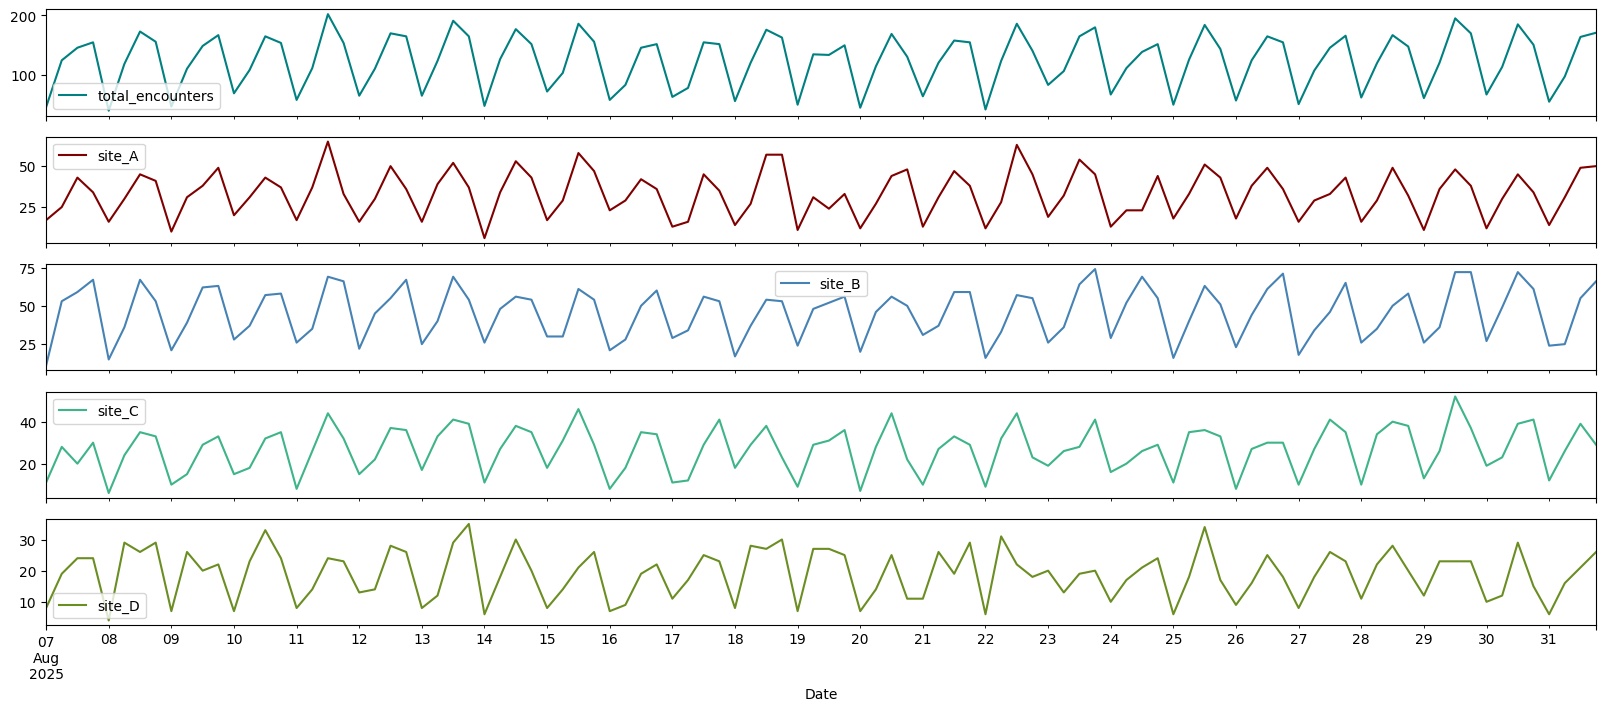

In [7]:
grouped_by_site_hour = grouped_by_site_hour.reset_index().set_index('Date')

grouped_by_site_hour_block = grouped_by_site_hour.resample('6h').sum()
grouped_by_site_hour_block = grouped_by_site_hour_block.drop(['unique_entry_per_day', 'total_admissions', 'Site'], axis=1)
grouped_by_site_hour_block['site_A'] = (grouped_by_site_hour[grouped_by_site_hour['Site'] == 'A'].resample('6h').sum())['total_encounters']
grouped_by_site_hour_block['site_B'] = (grouped_by_site_hour[grouped_by_site_hour['Site'] == 'B'].resample('6h').sum())['total_encounters']
grouped_by_site_hour_block['site_C'] = (grouped_by_site_hour[grouped_by_site_hour['Site'] == 'C'].resample('6h').sum())['total_encounters']
grouped_by_site_hour_block['site_D'] = (grouped_by_site_hour[grouped_by_site_hour['Site'] == 'D'].resample('6h').sum())['total_encounters']

grouped_by_site_hour_block[-100:].plot(subplots=True, figsize=(20,8))
plt.show()

In [8]:
full = grouped_by_site_hour_block.agg('sum')
site_A_ratio = full.site_A / full.total_encounters
site_B_ratio = full.site_B / full.total_encounters
site_C_ratio = full.site_C / full.total_encounters
site_D_ratio = full.site_D / full.total_encounters


# Monthly Model

In [9]:
df = pd.read_csv('./data/grouped_by_year_month.csv', parse_dates=['Date'])
df = df.set_index('Date')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])

In [10]:
def normalize(df): 
    df['total_enc_norm'] = df.total_encounters / df.index.days_in_month  # normalize with days in month to acount for february for example
    df = df.drop('total_encounters', axis=1)
    return df
    
def revert(df):
    df['total_encounters'] = df.total_enc_norm * df.index.days_in_month
    df = df.drop('total_enc_norm', axis=1)
    return df

In [11]:
df = normalize(df)

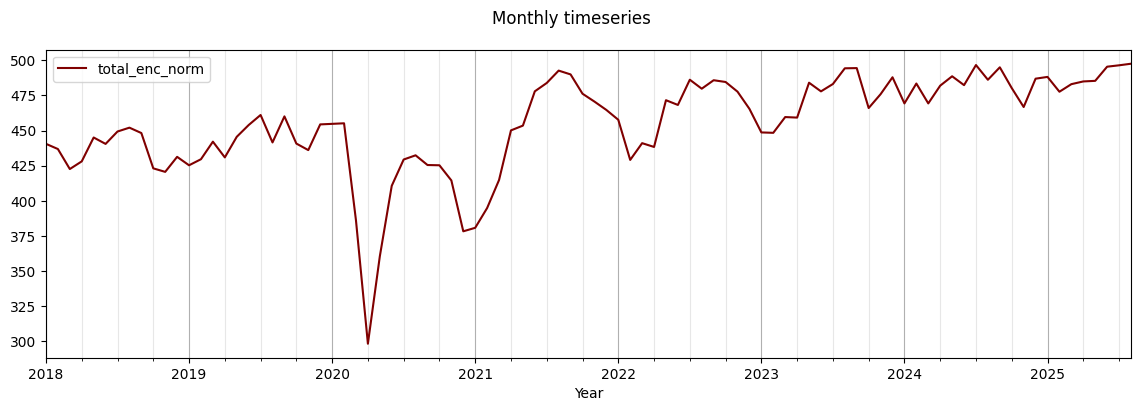

In [12]:
df.plot(
    kind='line',
    figsize=(14,4),
    color='maroon',
)
plt.grid(axis='x')
plt.grid(which='minor', axis='x', alpha=0.3)
plt.legend()
plt.suptitle('Monthly timeseries')
plt.xlabel('Year')
plt.show()

In [13]:
# Check stationarity (w/o correction)
ad_index = adfuller(df['2021':])[0] # we ignore the outlier 2020
p_val = adfuller(df['2021':])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')


Adfuller Index: -0.31365154249733285
p-val: 0.9235484881242906
Stationarity: False


In [14]:
# Make stationary
diff = np.diff(df.total_enc_norm, n=1)

ad_index = adfuller(diff[36:])[0]
p_val = adfuller(diff[36:])[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -6.747466429323355
p-val: 3.0095541151060984e-09
Stationarity: True


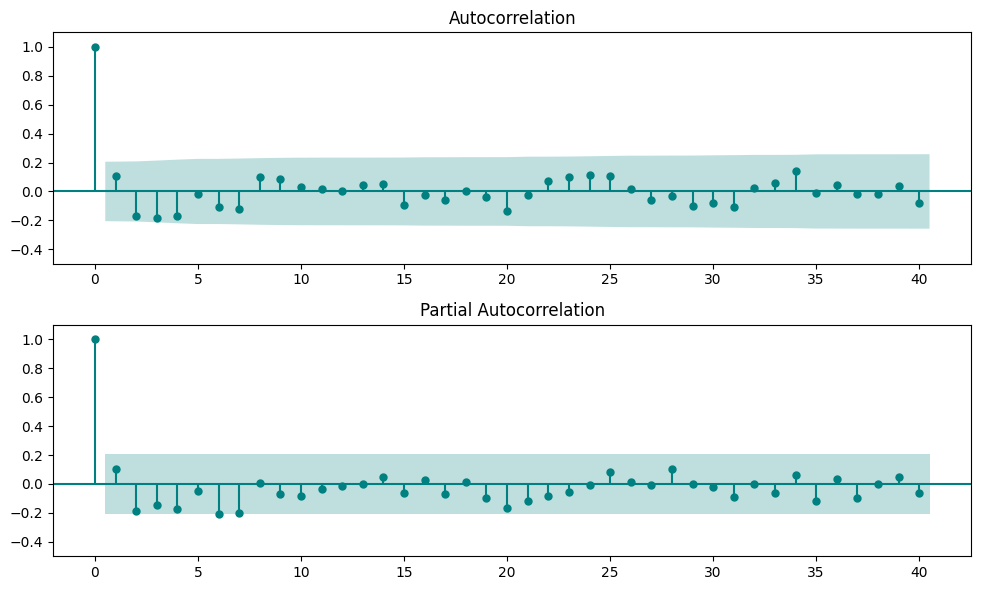

In [15]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff, lags=LAGS, ax=ax[0])
# ax[0].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-.5,1.1)

plot_pacf(diff, lags=LAGS, ax=ax[1])
# ax[1].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-.5,1.1)

plt.tight_layout()
plt.show()

In [16]:
# train on the full dataset
model = pm.auto_arima(
    y=df['total_enc_norm'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   92
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -399.321
Date:                Fri, 13 Feb 2026   AIC                            800.643
Time:                        23:29:08   BIC                            803.154
Sample:                    01-01-2018   HQIC                           801.656
                         - 08-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       379.3499     28.868     13.141      0.000     322.770     435.930
===================================================================================
Ljung-Box (L1) (Q):                   1.05   Jarque-Bera (JB):               140.06
Prob(Q):                              0.31   Prob(JB):                         0.00
Heteroskedasticity (H):               0.19   Skew:                            -1.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

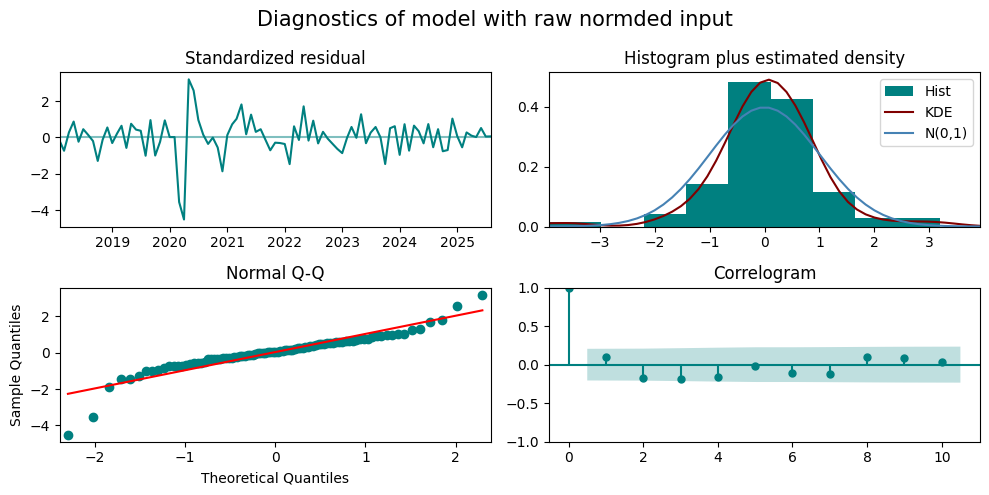

In [17]:
model.plot_diagnostics(figsize=(10,5))
plt.suptitle('Diagnostics of model with raw normded input', fontsize=15)
plt.tight_layout()
plt.show()

In [18]:
preds = model.predict(n_periods=2)
monthly_preds = revert(pd.DataFrame(preds, columns=['total_enc_norm']))

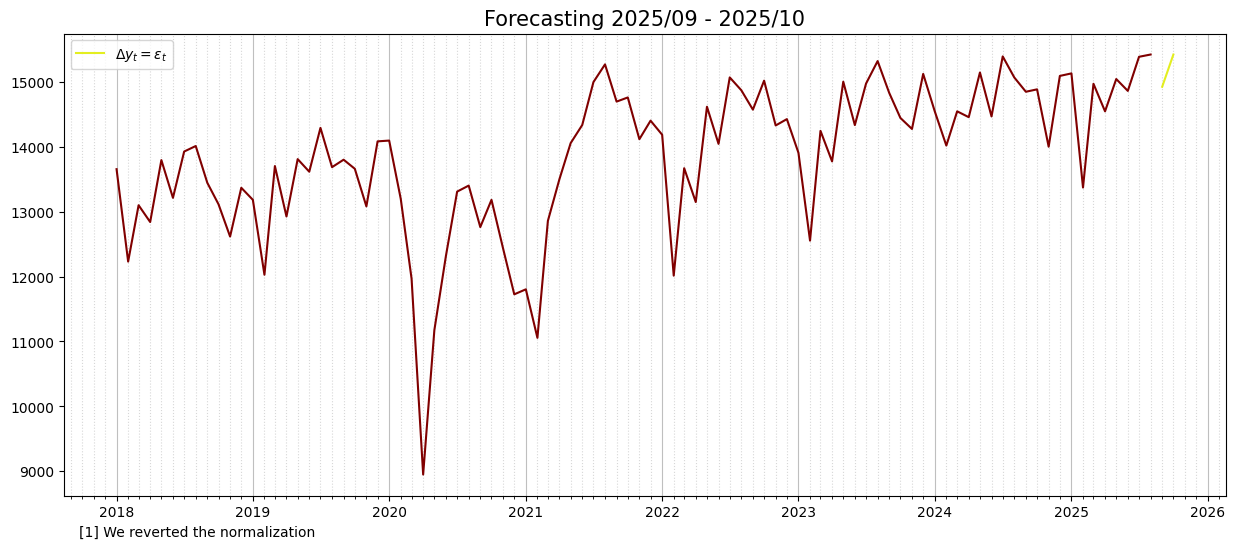

In [19]:
plt.figure(figsize=(15,6))
ax = plt.gca()

plt.plot(
    revert(df['total_enc_norm'].to_frame()),
    color='maroon'
)

plt.plot(
    monthly_preds,
    color="#E0EC00DF",
    # label=model.summary().tables[0].data[1][1]
    label = r'$\Delta y_t = \epsilon_t$'
    
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
plt.grid(which='minor', axis='x', linestyle=':', alpha=0.5)
plt.grid(which='major', axis='x', linestyle='-', alpha=0.8)
plt.legend()
plt.title('Forecasting 2025/09 - 2025/10', fontsize=15)
plt.text(x=df.index.min()-dt.timedelta(days=100) ,y=8000, s='[1] We reverted the normalization')
plt.show()

# Hourly

In [20]:
df = pd.read_csv('./data/grouped_by_site_hour_block.csv', parse_dates=['Date'])
first_value = df.iloc[0]
df['detrended_te'] = df['total_encounters'].diff(1)
display(df.dropna(inplace=True))

date_time = df.pop('Date')

None

2026-02-13 23:29:08.592485: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


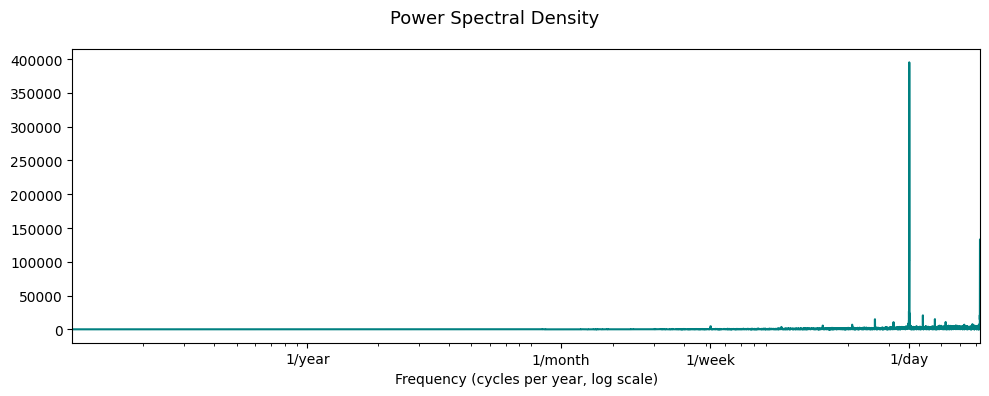

In [21]:
timestamp_s = date_time.map(pd.Timestamp.timestamp) # we convert to seconds

sampling_interval = 6 * 3600  # 6 hours in seconds

fft = tf.signal.rfft(df['detrended_te'])
f_per_dataset = np.arange(0, len(fft))

freq_hz = np.fft.rfftfreq(
    len(df['detrended_te']),
    d=sampling_interval
)

day = 24 * 60 * 60
year = 365.2425 * day

freq_per_year = freq_hz * year

plt.figure(figsize=(10,4))

plt.step(freq_per_year, np.abs(fft))
plt.xscale('log')
plt.xlim([0.1, max(freq_per_year)])

plt.xticks(
    [1, 12, 52, 365.2425],
    ['1/year', '1/month', '1/week', '1/day']
)
plt.xlabel('Frequency (cycles per year, log scale)')
plt.suptitle('Power Spectral Density', fontsize=13)
plt.tight_layout()
plt.show()


In [22]:
block_of_hour = 6 * 60 * 60
day = 4 * block_of_hour
week = 7 * day
year = 365.2425 * day
month = year / 12  # average month length

# first day harmonic 
df['day_sin_1'] = np.sin(2 * np.pi * timestamp_s / day)
df['day_cos_1'] = np.cos(2 * np.pi * timestamp_s / day)
# second day harmonic
df['day_sin_2'] = np.sin(2 * np.pi * 2 * timestamp_s / day)
df['day_cos_2'] = np.cos(2 * np.pi * 2 * timestamp_s / day)
# third day harmonic
df['day_sin_3'] = np.sin(2 * np.pi * 3 * timestamp_s / day)
df['day_cos_3'] = np.cos(2 * np.pi * 3 * timestamp_s / day)

# first week harmonic 
df['Week_sin_1'] = np.sin(2 * np.pi * timestamp_s / week)
df['Week_cos_1'] = np.cos(2 * np.pi * timestamp_s / week)

# is weekend flag
df['is_weekend'] = date_time.dt.day_of_week >= 5

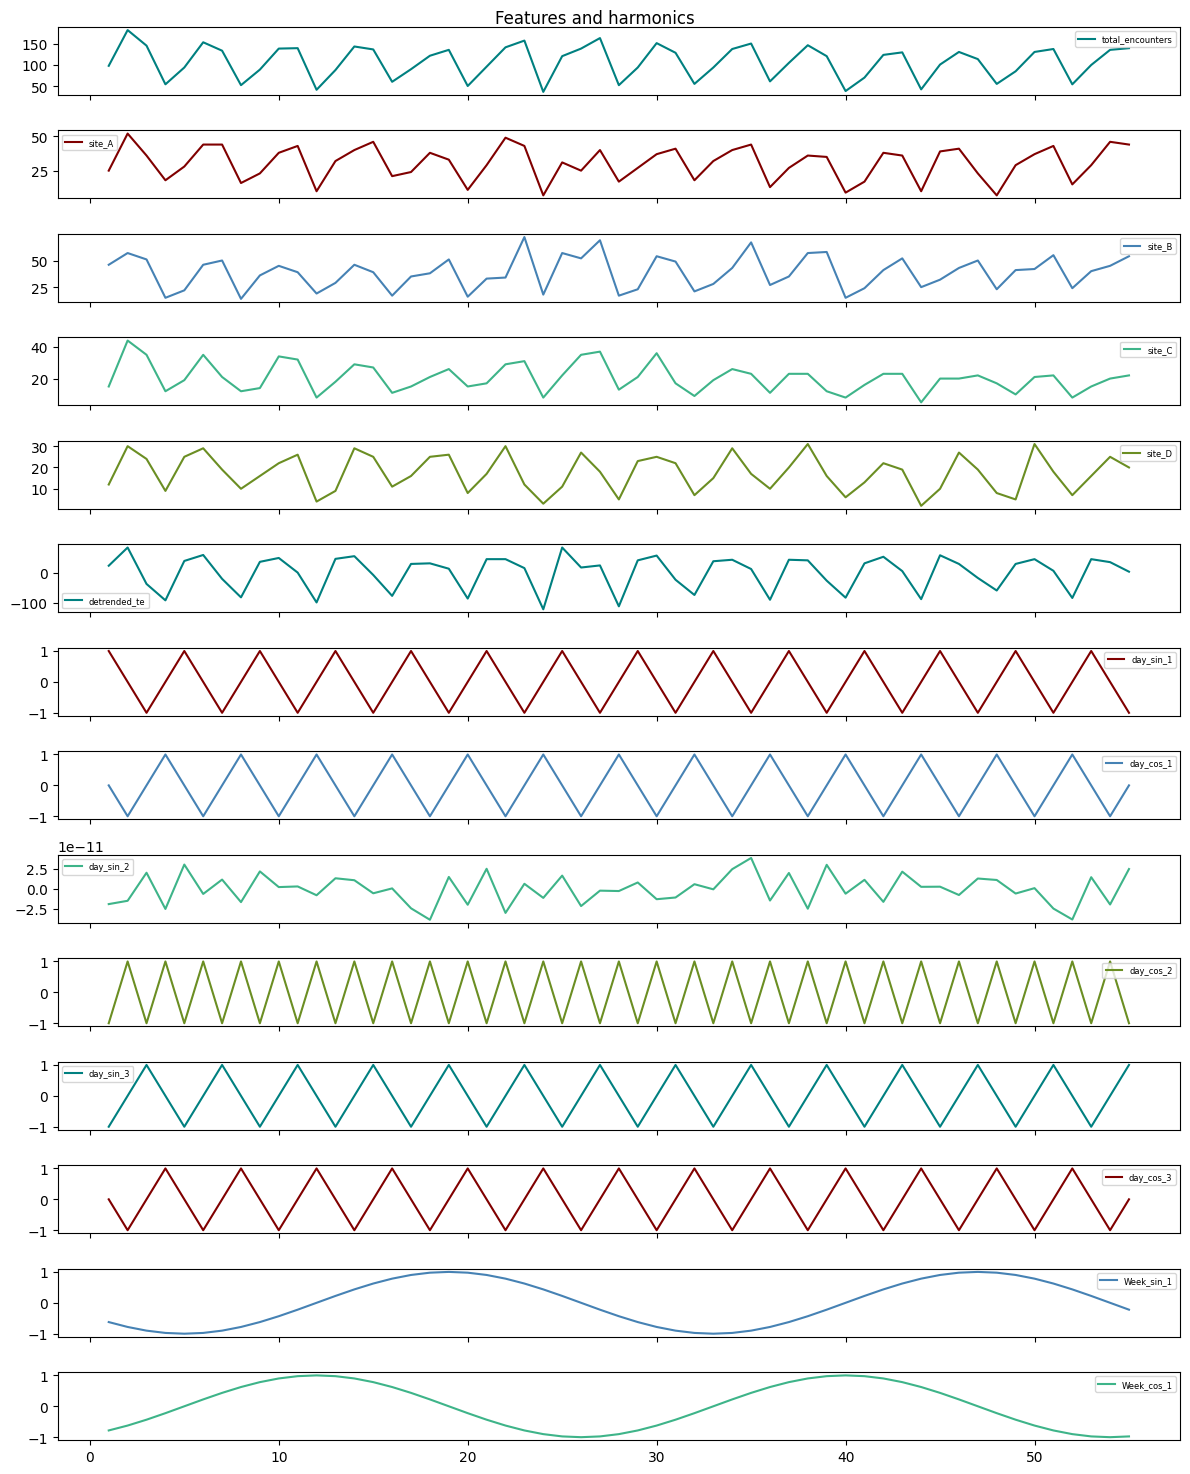

In [23]:
axes = df[:3+4*13].plot(subplots=True, figsize=(12,15))
for ax in axes:
    ax.legend(prop={'size': 6})
plt.suptitle("Features and harmonics", fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
df_mean = df.mean()
df_std = df.std()

df = (df - df_mean) / df.std()

In [25]:
# Env variables

BATCH_SIZE = 64

EPOCHS = 41
LR = 7e-4

LOOK_BACK = 4*120
OUT_STEPS = 4*60

# CNN
CONV_WIDTH = 4

# AR-LSTM
UNITS = 32

In [26]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df=None, val_df=None, test_df=None,
                 label_columns=None, batch_size=BATCH_SIZE):
        
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_ids = {name: i for i, name in 
                                      enumerate(label_columns)}
        
        self.column_ids = {name: i for i, name in
                           enumerate(train_df.columns)}
        
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        # Work out input ids
        self.input_slice = slice(0, input_width)
        self.input_ids = np.arange(self.total_window_size)[self.input_slice]

        # Work out label ids
        self.labels_start = self.total_window_size - label_width
        self.label_slice = slice(self.labels_start, None)
        self.label_ids = np.arange(self.total_window_size)[self.label_slice]



    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_ids}',
            f'Label indices: {self.label_ids}',
            f'Label column name(s): {self.label_columns}'])
    
    def split_window(self, features):
        # features.shape = (batch_size, time, features)
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.label_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_ids[name]] for name in self.label_columns],
                axis=-1
            )

        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels
    
    def plot(self, model=None, plot_col='total_encounters', max_subplots=4, figsize=(20, 10)):
        inputs, labels = self.example
        plt.figure(figsize=figsize)
        plot_col_index = self.column_ids[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.xlim((0, self.total_window_size))

            plt.plot(self.input_ids, inputs[n, :, plot_col_index],
                    label='Inputs', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_ids.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.plot(self.label_ids, labels[n, :, label_col_index],
                        label='Labels', ls = '--', lw=1.5, alpha=0.6)
            if model is not None:
                predictions = model(inputs)
                plt.plot(self.label_ids, predictions[n, :, label_col_index],
                            label='Predictions',
                            )

            if n == 0:
                plt.legend()

        plt.xlabel('Time [h]')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=self.batch_size
        )
        
        # do the split (inputs, labels) -> inputs, labels
        ds = ds.map(self.split_window)
        return ds
    
    @property
    def train(self):
        return self.make_dataset(self.train_df)
    
    @property
    def val(self):
        return self.make_dataset(self.val_df)
    
    @property
    def test(self):
        return self.make_dataset(self.test_df)
    
    @property
    def example(self):
        result = getattr(self, '_example', None)
        if result is None:
            result = next(iter(self.train))
            self._example = result
        return result

In [27]:
# Helper function 
def compile_and_fit(model, window, epochs = EPOCHS, lr=LR):

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-9),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=epochs)
  return history

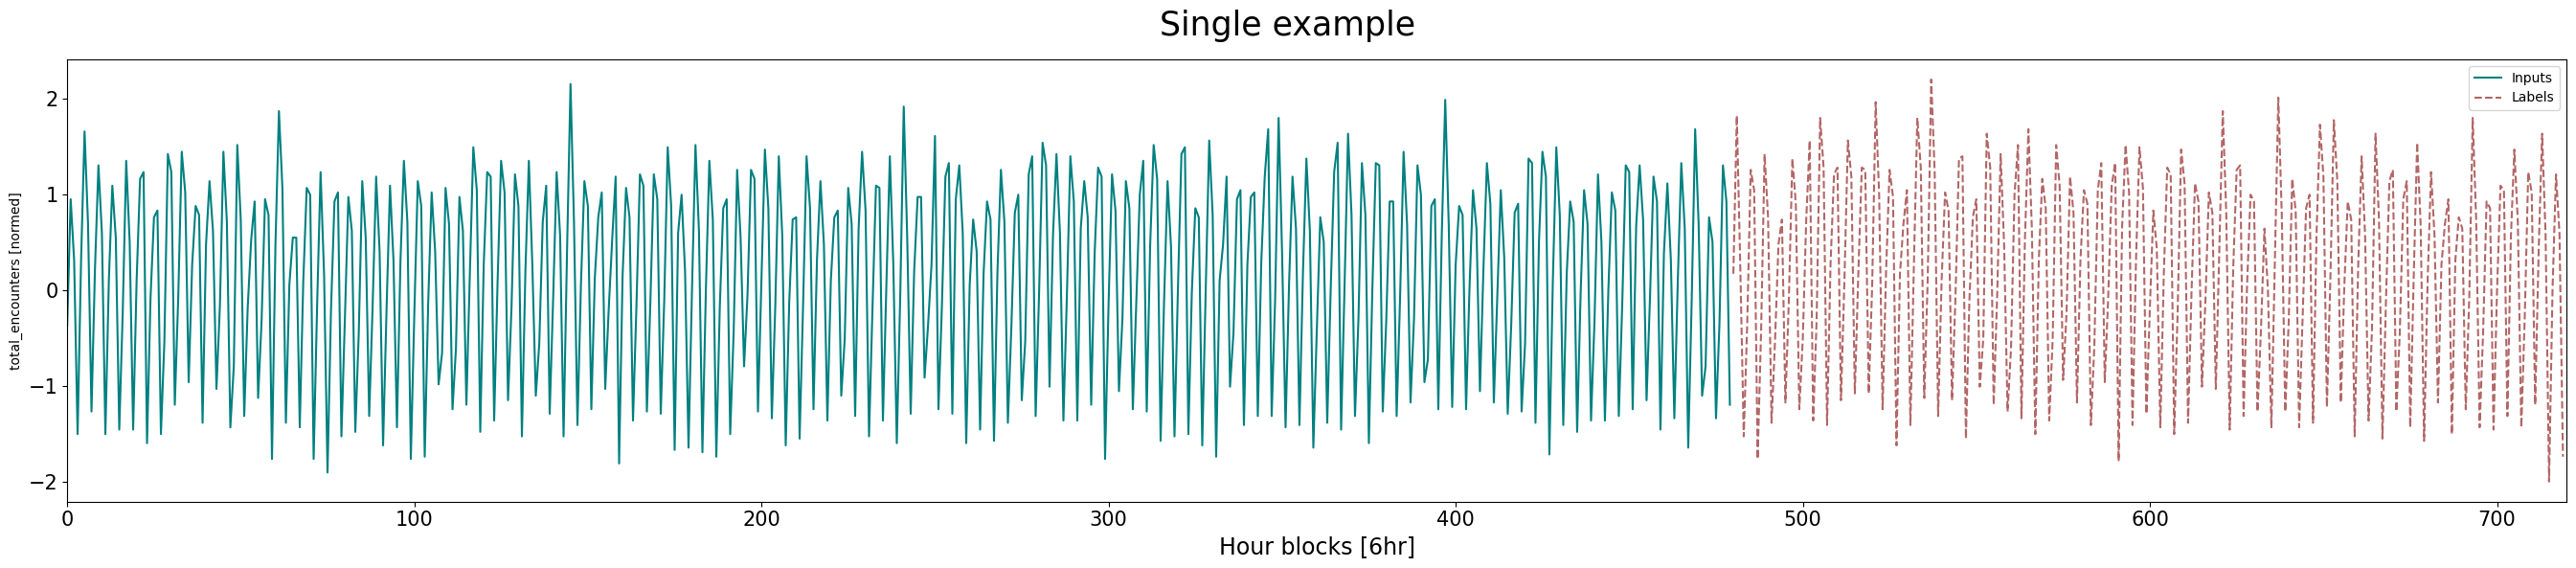

In [28]:
multi_window = WindowGenerator(input_width=LOOK_BACK,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=BATCH_SIZE,
                               train_df=df
                               )
multi_window.input_ids.shape, multi_window.label_ids.shape


multi_window.plot(max_subplots=1, figsize=(27,6))
plt.suptitle('Single example', fontsize=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Hour blocks [6hr]', fontsize=17)
plt.tight_layout()
plt.show()

Epoch 1/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 0.3097 - mean_absolute_error: 0.3735
Epoch 2/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.1594 - mean_absolute_error: 0.2403
Epoch 3/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - loss: 0.1568 - mean_absolute_error: 0.2373
Epoch 4/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.1443 - mean_absolute_error: 0.2233
Epoch 5/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.1404 - mean_absolute_error: 0.2186
Epoch 6/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.1400 - mean_absolute_error: 0.2179
Epoch 7/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - loss: 0.1388 - mean_absolute_error: 0.2171
Epoch 8/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.1340 - mean_absolute_error: 0.2144
Epoch 9/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.1303 - mean_absolute_error: 0.2120
Epoch 10/41
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.1294 - mean_absolute_error: 0.2112
Epoch 11/

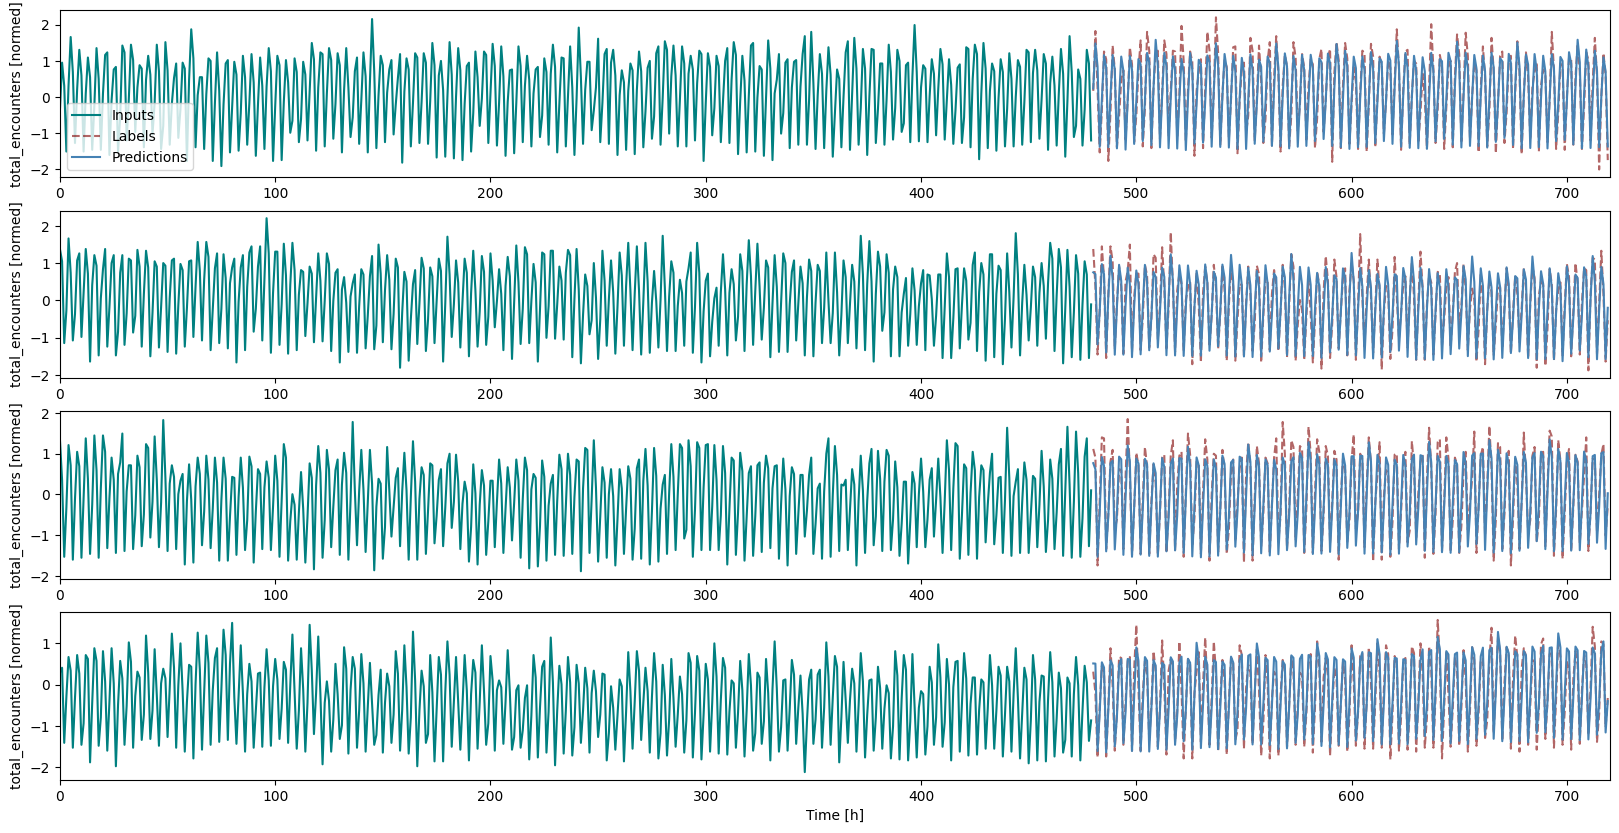

In [29]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=CONV_WIDTH, strides=1),
    tf.keras.layers.Conv1D(64, kernel_size=14*CONV_WIDTH, strides=7),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(1024, activation='tanh'),
    tf.keras.layers.Dense(15*240),
    tf.keras.layers.Reshape((240,15))

])

history = compile_and_fit(cnn, multi_window, lr=LR)

# IPython.display.clear_output()
multi_window.plot(cnn)


In [30]:
timestamps = pd.date_range(
    start="2025-09-01 00:00",
    periods=len(preds),
    freq="6H"
)

timestamps = list(timestamps)


/tmp/ipykernel_180853/1045546930.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = pd.date_range(


In [31]:
preds_normed = cnn(df[-480:].to_numpy()[None, :, :])

preds = preds_normed * df_std + df_mean
preds

<tf.Tensor: shape=(1, 240, 15), dtype=float32, numpy=
array([[[ 5.5134125e+01,  1.6581013e+01,  2.1205482e+01, ...,
         -4.3734962e-01, -8.8943386e-01,  1.1179417e-02],
        [ 1.2629435e+02,  3.2788898e+01,  4.5869705e+01, ...,
         -6.2232214e-01, -7.7172172e-01,  1.9618034e-02],
        [ 1.7716858e+02,  4.9070015e+01,  6.2539597e+01, ...,
         -7.7721649e-01, -6.1485243e-01, -1.4765978e-02],
        ...,
        [ 1.1014338e+02,  3.0975359e+01,  3.8143391e+01, ...,
          2.2615631e-01,  9.6668684e-01, -1.3430655e-02],
        [ 1.5550009e+02,  4.2848259e+01,  5.4010677e+01, ...,
          4.3636265e-01,  8.9276397e-01, -3.0243695e-03],
        [ 1.3742360e+02,  3.5381123e+01,  5.3161655e+01, ...,
          6.2587404e-01,  7.7223337e-01, -5.0346553e-03]]],
      shape=(1, 240, 15), dtype=float32)>

In [39]:
def boundary_reconcile(preds, dates, sarima_forecasts):
    """
    Reconcile 6-hour LSTM predictions to SARIMA monthly totals.
    
    preds: 1D numpy array (num_blocks,)
    dates: list of pd.Timestamp
    sarima_forecasts: dict {(month, year): monthly_total}
    """
    
    dates = pd.to_datetime(dates)
    
    reconciled_preds = np.zeros_like(preds)
    
    unique_periods = sorted({(d.month, d.year) for d in dates})
    
    for month, year in unique_periods:
        mask = np.array(
            [(d.month == month and d.year == year) for d in dates]
        )
        
        monthly_total = sarima_forecasts[(month, year)]
        
        num_blocks = mask.sum()
        
        sarima_block_avg = monthly_total / num_blocks
        print(mask)
        lstm_segment_avg = np.mean(preds[mask])
        
        k = sarima_block_avg / lstm_segment_avg if lstm_segment_avg != 0 else 0
        
        reconciled_preds[mask] = preds[mask] * k
    
    return reconciled_preds


In [ ]:
    unique_periods = sorted({(d.month, d.year) for d in dates})
    
    for month, year in unique_periods:
        mask = np.array(
            [(d.month == month and d.year == year) for d in dates]
        )
        
        monthly_total = sarima_forecasts[(month, year)]
        
        num_blocks = mask.sum()
        
        sarima_block_avg = monthly_total / num_blocks
        print(mask)

In [33]:
dictionary = monthly_preds.set_index([monthly_preds.index.month, monthly_preds.index.year]).to_dict()['total_encounters']

In [40]:
from collections import defaultdict

pred_dict = defaultdict(list)

preds_total_r = boundary_reconcile(
    preds=preds.numpy().squeeze(axis=0)[:,0],
    dates = timestamps,
    sarima_forecasts=dictionary
)

p_A = preds.numpy().squeeze(axis=0)[:,1]
p_B = preds.numpy().squeeze(axis=0)[:,2]
p_C = preds.numpy().squeeze(axis=0)[:,3]
p_D = preds.numpy().squeeze(axis=0)[:,4]

r_A = (p_A + preds_total_r*site_A_ratio) / 2
r_B = (p_B + preds_total_r*site_B_ratio) / 2
r_C = (p_C + preds_total_r*site_C_ratio) / 2
r_D = (p_D + preds_total_r*site_D_ratio) / 2

for i in range(len(preds_total_r)):

    hour_block = timestamps[i].hour // 6
    timestamp = timestamps[i]

    pred_dict[("Total", timestamp, hour_block)].append(preds_total_r[i])
    pred_dict[("A", timestamp, hour_block)].append(r_A[i])
    pred_dict[("B", timestamp, hour_block)].append(r_B[i])
    pred_dict[("C", timestamp, hour_block)].append(r_C[i])
    pred_dict[("D", timestamp, hour_block)].append(r_D[i])


rows = []

for (site, timestamp, hour_block), values in pred_dict.items():
    rows.append({
        "Site": site,
        "Date": timestamp,
        "Hour Block": hour_block,
        "ED Env Prediction": np.mean(values)  # average overlapping predictions
    })

forecast_df = pd.DataFrame(rows)
forecast_df = forecast_df.sort_values(["Date", "Site"]).reset_index(drop=True)

[ True  True]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 240 but size of corresponding boolean axis is 2

In [ ]:
forecast_df

,Site,Date,Hour Block,ED Env Prediction
0,A,2025-09-01 00:00:00,0,16.017544
1,B,2025-09-01 00:00:00,0,22.640158
2,C,2025-09-01 00:00:00,0,12.053796
3,D,2025-09-01 00:00:00,0,8.622334
4,Total,2025-09-01 00:00:00,0,60.113041
...,...,...,...,...
1195,A,2025-10-30 18:00:00,3,37.764641
1196,B,2025-10-30 18:00:00,3,54.225014
1197,C,2025-10-30 18:00:00,3,30.343155
1198,D,2025-10-30 18:00:00,3,22.141857


In [ ]:
forecast_df.to_csv('./data/forecast_sep_oct.csv')
